# IMDb Sentiment Analysis - Exploratory Data Analysis

This notebook explores the IMDb movie review dataset loaded from CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path
import sys

sys.path.append(str(Path('../')))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
csv_path = '../data/IMDB Dataset.csv'
print(f'Loading dataset from {csv_path}...')
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f'Dataset loaded: {len(df)} reviews')
print(f'Columns: {list(df.columns)}')
df.head()

Loading dataset from ../data/IMDB Dataset.csv...
Dataset loaded: 50000 reviews
Columns: ['review', 'sentiment', 'label']


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


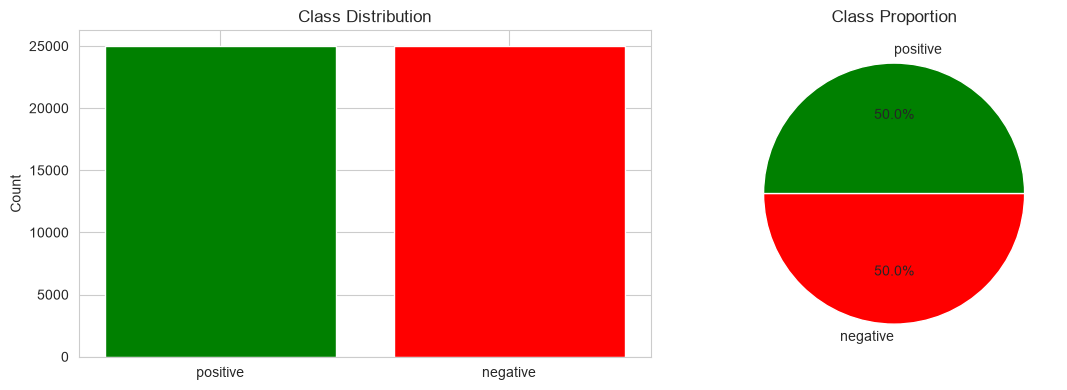

Dataset balance:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_counts = df['sentiment'].value_counts()

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print('Dataset balance:')
print(sentiment_counts)

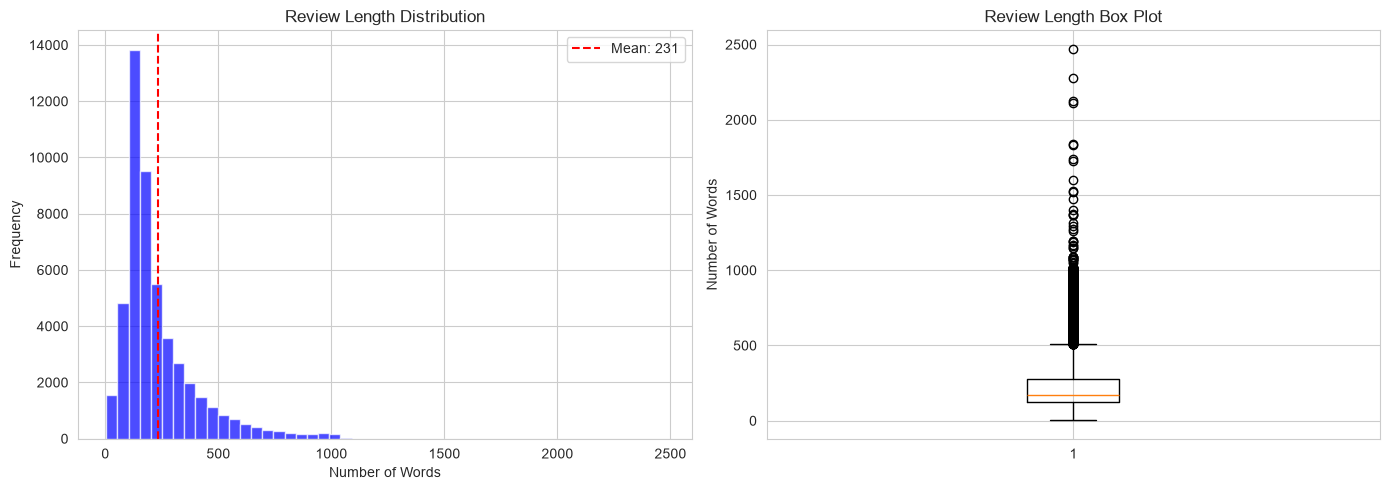

In [4]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['review_length'], bins=50, alpha=0.7, color='blue')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Review Length Distribution')
axes[0].axvline(df['review_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["review_length"].mean():.0f}')
axes[0].legend()

axes[1].boxplot(df['review_length'])
axes[1].set_ylabel('Number of Words')
axes[1].set_title('Review Length Box Plot')

plt.tight_layout()
plt.show()

In [5]:
print('='*80)
print('SAMPLE REVIEWS FROM DATASET')
print('='*80)

for sentiment in ['positive', 'negative']:
    sample = df[df['sentiment'] == sentiment].sample(2, random_state=42)
    print(f'\n{sentiment.upper()} REVIEWS:')
    print('-'*80)
    for idx, row in sample.iterrows():
        print(f'Review {idx}:')
        print(row['review'][:300] + '...' if len(row['review']) > 300 else row['review'])
        print()

SAMPLE REVIEWS FROM DATASET

POSITIVE REVIEWS:
--------------------------------------------------------------------------------
Review 13886:
I don't know how or why this film has a meager rating on IMDb. This film, accompanied by "I am Curious: Blue" is a masterwork.<br /><br />The only thing that will let you down in this film is if you don't like the process of film, don't like psychology or if you were expecting hardcore pornographic ...

Review 48027:
For a long time it seemed like all the good Canadian actors had headed south of the border and (I guessed) all the second rank ones filled the top slots and that left the dregs for the sex comedies.<br /><br />This film was a real surprise: despite the outlandish plots that are typical of farces, th...


NEGATIVE REVIEWS:
--------------------------------------------------------------------------------
Review 13625:
I was looking forward to seeing Bruce Willis in this, especially since I remember being mesmerised by the original when 

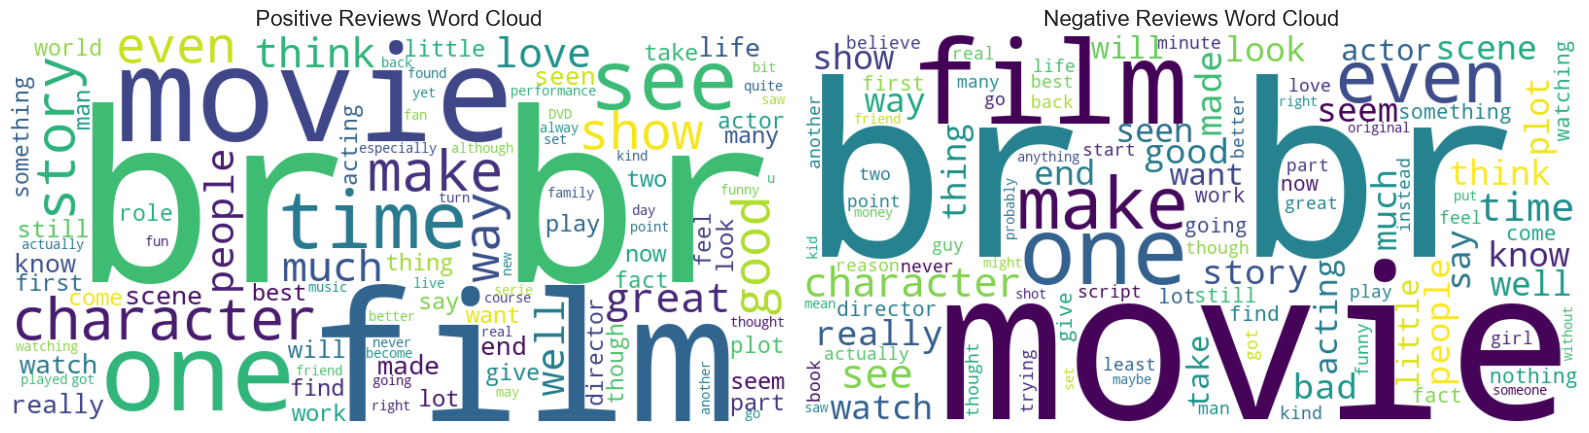

In [6]:
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review'].values)
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review'].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews Word Cloud', fontsize=16)
axes[0].axis('off')

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Key Insights

1. **Balanced Dataset**: 25K positive, 25K negative reviews
2. **Review Length**: Average ~230 words
3. **Vocabulary**: Rich movie-related vocabulary
4. **Ready for Training**: Dataset is clean and ready for fine-tuning